In [11]:
import pandas as pd


In [12]:
raw_preview = pd.read_csv(
    "../data/raw/lastfm/lastfm-dataset-360k/usersha1-artmbid-artname-plays.tsv",
    sep="\t", header=None, nrows=10
)
raw_preview

,0,1,2,3
0,00000c289a1829a808ac09c00daf10bc3c4e223b,3bd73256-3905-4f3a-97e2-8b341527f805,betty blowtorch,2137
1,00000c289a1829a808ac09c00daf10bc3c4e223b,f2fb0ff0-5679-42ec-a55c-15109ce6e320,die Ärzte,1099
2,00000c289a1829a808ac09c00daf10bc3c4e223b,b3ae82c2-e60b-4551-a76d-6620f1b456aa,melissa etheridge,897
3,00000c289a1829a808ac09c00daf10bc3c4e223b,3d6bbeb7-f90e-4d10-b440-e153c0d10b53,elvenking,717
4,00000c289a1829a808ac09c00daf10bc3c4e223b,bbd2ffd7-17f4-4506-8572-c1ea58c3f9a8,juliette & the licks,706
5,00000c289a1829a808ac09c00daf10bc3c4e223b,8bfac288-ccc5-448d-9573-c33ea2aa5c30,red hot chili peppers,691
6,00000c289a1829a808ac09c00daf10bc3c4e223b,6531c8b1-76ea-4141-b270-eb1ac5b41375,magica,545
7,00000c289a1829a808ac09c00daf10bc3c4e223b,21f3573f-10cf-44b3-aeaa-26cccd8448b5,the black dahlia murder,507
8,00000c289a1829a808ac09c00daf10bc3c4e223b,c5db90c4-580d-4f33-b364-fbaa5a3a58b5,the murmurs,424
9,00000c289a1829a808ac09c00daf10bc3c4e223b,0639533a-0402-40ba-b6e0-18b067198b73,lunachicks,403


In [13]:
raw_preview.head(5)

,0,1,2,3
0,00000c289a1829a808ac09c00daf10bc3c4e223b,3bd73256-3905-4f3a-97e2-8b341527f805,betty blowtorch,2137
1,00000c289a1829a808ac09c00daf10bc3c4e223b,f2fb0ff0-5679-42ec-a55c-15109ce6e320,die Ärzte,1099
2,00000c289a1829a808ac09c00daf10bc3c4e223b,b3ae82c2-e60b-4551-a76d-6620f1b456aa,melissa etheridge,897
3,00000c289a1829a808ac09c00daf10bc3c4e223b,3d6bbeb7-f90e-4d10-b440-e153c0d10b53,elvenking,717
4,00000c289a1829a808ac09c00daf10bc3c4e223b,bbd2ffd7-17f4-4506-8572-c1ea58c3f9a8,juliette & the licks,706


In [14]:
raw_preview11 = pd.read_csv(
    "../data/raw/lastfm/lastfm-dataset-360k/usersha1-profile.tsv",sep="\t", header=None, nrows=10)
raw_preview11

,0,1,2,3,4
0,00000c289a1829a808ac09c00daf10bc3c4e223b,f,22.0,Germany,"Feb 1, 2007"
1,00001411dc427966b17297bf4d69e7e193135d89,f,NaN,Canada,"Dec 4, 2007"
2,00004d2ac9316e22dc007ab2243d6fcb239e707d,NaN,NaN,Germany,"Sep 1, 2006"
3,000063d3fe1cf2ba248b9e3c3f0334845a27a6bf,m,19.0,Mexico,"Apr 28, 2008"
4,00007a47085b9aab8af55f52ec8846ac479ac4fe,m,28.0,United States,"Jan 27, 2006"
5,0000c176103e538d5c9828e695fed4f7ae42dd01,m,20.0,United Kingdom,"Jan 14, 2006"
6,0000ee7dd906373efa37f4e1185bfe1e3f8695ae,m,17.0,Finland,"Nov 17, 2007"
7,0000ef373bbd0d89ce796abae961f2705e8c1faf,f,22.0,Poland,"May 23, 2007"
8,0000f687d4fe9c1ed49620fbc5ed5b0d7798ea20,f,24.0,Spain,"Nov 4, 2008"
9,0001399387da41d557219578fb08b12afa25ab67,m,NaN,Ukraine,"Aug 17, 2008"


In [15]:
print(raw_preview.shape)
print(raw_preview.dtypes)

(10, 4)
0      str
1      str
2      str
3    int64
dtype: object


In [16]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve()
while PROJECT_ROOT != PROJECT_ROOT.parent and not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.data.loader import load_lastfm_interactions

interactions_raw = load_lastfm_interactions(
    "../data/raw/lastfm/lastfm-dataset-360k/usersha1-artmbid-artname-plays.tsv"
)
print(f"Loaded {len(interactions_raw):,} rows")
interactions_raw.head()

Loaded 17,535,450 rows


,user_id,artist_name,plays
0,00000c289a1829a808ac09c00daf10bc3c4e223b,betty blowtorch,2137
1,00000c289a1829a808ac09c00daf10bc3c4e223b,die Ärzte,1099
2,00000c289a1829a808ac09c00daf10bc3c4e223b,melissa etheridge,897
3,00000c289a1829a808ac09c00daf10bc3c4e223b,elvenking,717
4,00000c289a1829a808ac09c00daf10bc3c4e223b,juliette & the licks,706


In [17]:
print("Missing values in interactions_raw:")
print(interactions_raw.isnull().sum())
print("Percentage of missing values in interactions_raw:")
print((interactions_raw.isnull().sum() / len(interactions_raw) * 100).round(2))

Missing values in interactions_raw:
user_id        0
artist_name    0
plays          0
dtype: int64
Percentage of missing values in interactions_raw:
user_id        0.0
artist_name    0.0
plays          0.0
dtype: float64


In [18]:
# Drop rows with missing artist_name (can't recover this — no other identifier)
before = len(interactions_raw)
interactions_raw = interactions_raw.dropna(subset=["artist_name"])
after = len(interactions_raw)
print(f"Dropped {before - after:,} rows with missing artist_name ({(before-after)/before*100:.3f}%)")

Dropped 0 rows with missing artist_name (0.000%)


In [19]:
# Are there duplicate (user_id, artist_name) pairs?
dupe_count = interactions_raw.duplicated(subset=["user_id", "artist_name"]).sum()
print(f"Duplicate (user, artist) pairs: {dupe_count:,}")

Duplicate (user, artist) pairs: 75


In [20]:
if dupe_count > 0:
    # Inspect a few examples before deciding
    dupes = interactions_raw[interactions_raw.duplicated(subset=["user_id", "artist_name"], keep=False)]
    print(dupes.sort_values(["user_id", "artist_name"]).head(10))

                                         user_id artist_name  plays
69147   00f9e7b0462685f293dc09c28a5efdc971095409   delirious    141
69175   00f9e7b0462685f293dc09c28a5efdc971095409   delirious     86
260917  03d773fc144d1aa005e6d40c40912cd5921e3524       タテタカコ    179
260934  03d773fc144d1aa005e6d40c40912cd5921e3524       タテタカコ    123
312791  049f1a9fcffff1a3ff38042348b7b3fbb5c0f46e    big bang    888
312796  049f1a9fcffff1a3ff38042348b7b3fbb5c0f46e    big bang    363
563426  083ad4034c1b79cb7e30d555a82ef21fc2decb7f    big bang    534
563431  083ad4034c1b79cb7e30d555a82ef21fc2decb7f    big bang    263
961510  0e0e321fa773a3e73ef719fb72c05b73f2f54a9f        ゴダイゴ    236
961525  0e0e321fa773a3e73ef719fb72c05b73f2f54a9f        ゴダイゴ    124


In [ ]:
interactions_raw = (
    interactions_raw.groupby(["user_id", "artist_name"], as_index=False)["plays"].sum()
)
interactions_raw

,user_id,artist_name,plays
0,00000c289a1829a808ac09c00daf10bc3c4e223b,all ends,229
1,00000c289a1829a808ac09c00daf10bc3c4e223b,all:my:faults,288
2,00000c289a1829a808ac09c00daf10bc3c4e223b,babes in toyland,310
3,00000c289a1829a808ac09c00daf10bc3c4e223b,betty,135
4,00000c289a1829a808ac09c00daf10bc3c4e223b,betty blowtorch,2137
...,...,...,...
17535370,"sep 20, 2008",these new puritans,12
17535371,"sep 20, 2008",tokyo police club,25
17535372,"sep 20, 2008",tomte,45
17535373,"sep 20, 2008",turbostaat,12


: 

In [22]:
# Sanity checks — these should never fail on clean data
assert (interactions_raw["plays"] > 0).all(), "Found non-positive play counts"
assert interactions_raw["user_id"].notna().all(), "Found null user_id"
assert interactions_raw["artist_name"].notna().all(), "Found null artist_name after cleanup"

# Check for absurd outliers — is there a user with 10 million plays on one artist? (likely bot/scraping artifact)
print(interactions_raw["plays"].describe())
print(f"\n99.9th percentile of plays: {interactions_raw['plays'].quantile(0.999):.0f}")
print(f"Max plays: {interactions_raw['plays'].max():,}")

count    1.753538e+07
mean     2.151956e+02
std      6.144883e+02
min      1.000000e+00
25%      3.500000e+01
50%      9.400000e+01
75%      2.240000e+02
max      4.191570e+05
Name: plays, dtype: float64

99.9th percentile of plays: 5876
Max plays: 419,157


In [23]:
(interactions_raw["plays"] <= 0).sum()

np.int64(0)

In [24]:
interactions_raw.loc[
    interactions_raw["plays"] <= 0,
    "plays"
].value_counts()

Series([], Name: count, dtype: int64)

In [25]:
interactions_raw[interactions_raw["plays"] == 0]

,user_id,artist_name,plays


In [26]:
interactions = interactions_raw.copy()

interactions = interactions[interactions["plays"] > 0]

In [27]:
assert (interactions["plays"] > 0).all()
assert interactions["user_id"].notna().all()
assert interactions["artist_name"].notna().all()

print("✅ All sanity checks passed.")

✅ All sanity checks passed.


In [28]:
print(interactions_raw["plays"].describe())
print(f"\n99.9th percentile of plays: {interactions_raw['plays'].quantile(0.999):.0f}")
print(f"Max plays: {interactions_raw['plays'].max():,}")

count    1.753538e+07
mean     2.151956e+02
std      6.144883e+02
min      1.000000e+00
25%      3.500000e+01
50%      9.400000e+01
75%      2.240000e+02
max      4.191570e+05
Name: plays, dtype: float64

99.9th percentile of plays: 5876
Max plays: 419,157


In [29]:
user_totals = interactions_raw.groupby("user_id")["plays"].sum()
print(user_totals.describe())
print(f"\nMedian total plays per user: {user_totals.median():.0f}")
print(f"Mean total plays per user: {user_totals.mean():.0f}")

count    358868.000000
mean      10515.108107
std       14761.229630
min           1.000000
25%        2402.000000
50%        6140.000000
75%       13131.000000
max      787884.000000
Name: plays, dtype: float64

Median total plays per user: 6140
Mean total plays per user: 10515


In [30]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve()
while PROJECT_ROOT != PROJECT_ROOT.parent and not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
from src.data.sampler import stratified_sample_users

interactions_sample = stratified_sample_users(interactions_raw, n_samples=75000, random_seed=42)
print(f"Sampled interactions: {len(interactions_sample):,}")
print(f"Sampled users: {interactions_sample['user_id'].nunique():,}")

Sampled interactions: 3,664,980
Sampled users: 74,999


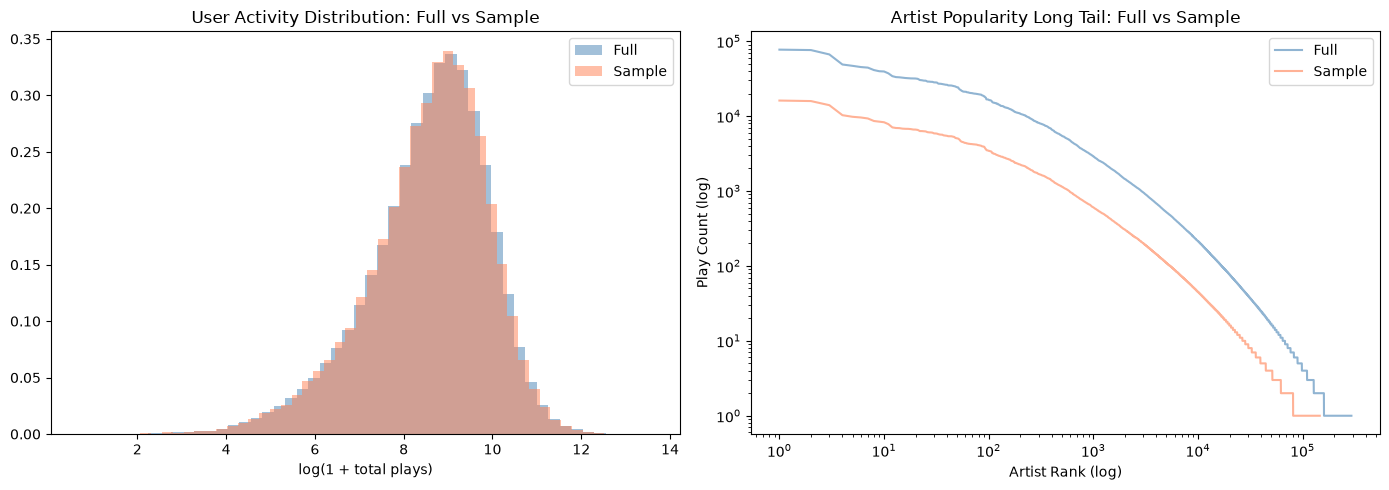

In [31]:
import matplotlib.pyplot as plt
import numpy as np

full_user_totals = interactions_raw.groupby("user_id")["plays"].sum()
sample_user_totals = interactions_sample.groupby("user_id")["plays"].sum()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot A: distribution of total plays per user, full vs sample
axes[0].hist(np.log1p(full_user_totals), bins=50, density=True, alpha=0.5, label="Full", color="steelblue")
axes[0].hist(np.log1p(sample_user_totals), bins=50, density=True, alpha=0.5, label="Sample", color="coral")
axes[0].set_xlabel("log(1 + total plays)")
axes[0].set_title("User Activity Distribution: Full vs Sample")
axes[0].legend()

# Plot B: artist popularity (long tail), full vs sample — log-log
full_artist_freq = interactions_raw["artist_name"].value_counts().values
sample_artist_freq = interactions_sample["artist_name"].value_counts().values

axes[1].loglog(range(1, len(full_artist_freq)+1), full_artist_freq, alpha=0.6, label="Full", color="steelblue")
axes[1].loglog(range(1, len(sample_artist_freq)+1), sample_artist_freq, alpha=0.6, label="Sample", color="coral")
axes[1].set_xlabel("Artist Rank (log)")
axes[1].set_ylabel("Play Count (log)")
axes[1].set_title("Artist Popularity Long Tail: Full vs Sample")
axes[1].legend()

plt.tight_layout()
plt.savefig("outputs/figures/sample_validation.png", dpi=150)
plt.show()

In [32]:
print(f"Interactions:  {len(interactions_sample):,}")
print(f"Unique users:  {interactions_sample['user_id'].nunique():,}")
print(f"Unique artists: {interactions_sample['artist_name'].nunique():,}")

Interactions:  3,664,980
Unique users:  74,999
Unique artists: 145,778


In [33]:
interactions_sample.shape

(3664980, 3)

In [34]:
interactions_raw.shape

(17535375, 3)

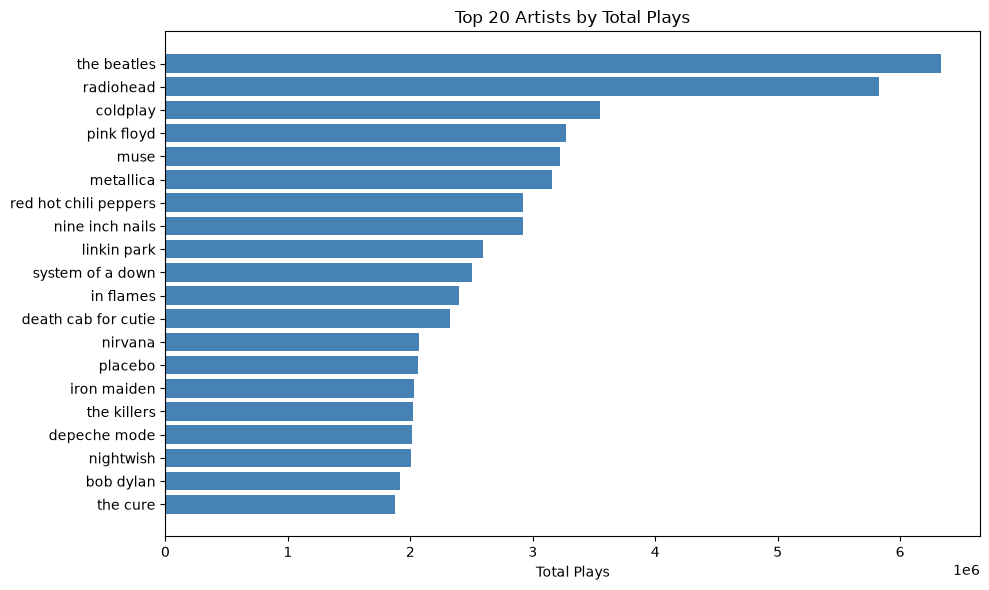

In [35]:
top_artists = (
    interactions_sample.groupby("artist_name")["plays"]
    .sum()
    .sort_values(ascending=False)
    .head(20)
)

plt.figure(figsize=(10, 6))
plt.barh(top_artists.index[::-1], top_artists.values[::-1], color="steelblue")
plt.xlabel("Total Plays")
plt.title("Top 20 Artists by Total Plays")
plt.tight_layout()
plt.savefig("outputs/figures/top_artists.png", dpi=150)

Top 1% of artists (1457 artists) account for 53.0% of all plays


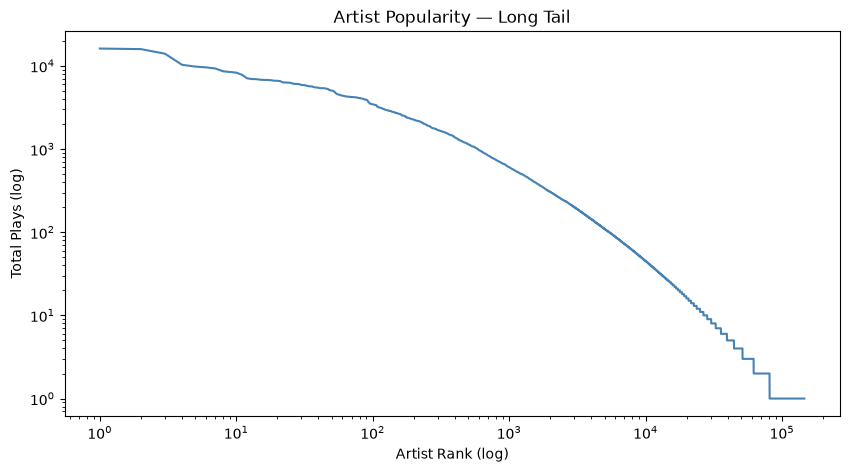

In [36]:
artist_freq = interactions_sample["artist_name"].value_counts().values

plt.figure(figsize=(10, 5))
plt.loglog(range(1, len(artist_freq)+1), artist_freq, color="steelblue")
plt.xlabel("Artist Rank (log)")
plt.ylabel("Total Plays (log)")
plt.title("Artist Popularity — Long Tail")
plt.savefig("outputs/figures/long_tail.png", dpi=150)

top_1pct_n = max(1, int(len(artist_freq) * 0.01))
top_1pct_share = artist_freq[:top_1pct_n].sum() / artist_freq.sum() * 100
print(f"Top 1% of artists ({top_1pct_n} artists) account for {top_1pct_share:.1f}% of all plays")

In [37]:
n_users = interactions_sample["user_id"].nunique()
n_artists = interactions_sample["artist_name"].nunique()
n_observed = len(interactions_sample)
n_possible = n_users * n_artists
sparsity = 1 - (n_observed / n_possible)

print(f"Matrix shape: {n_users:,} users x {n_artists:,} artists")
print(f"Observed entries: {n_observed:,} / {n_possible:,} possible")
print(f"Sparsity: {sparsity*100:.4f}%")



Matrix shape: 74,999 users x 145,778 artists
Observed entries: 3,664,980 / 10,933,204,222 possible
Sparsity: 99.9665%


In [38]:
tracks_df = pd.read_csv("../data/raw/spotify/dataset.csv")
print(tracks_df.shape)
print(tracks_df.isnull().sum())  # missing value check, same discipline as before

(114000, 21)
Unnamed: 0          0
track_id            0
artists             1
album_name          1
track_name          1
popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
track_genre         0
dtype: int64


In [39]:
tracks_df.head(5)

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


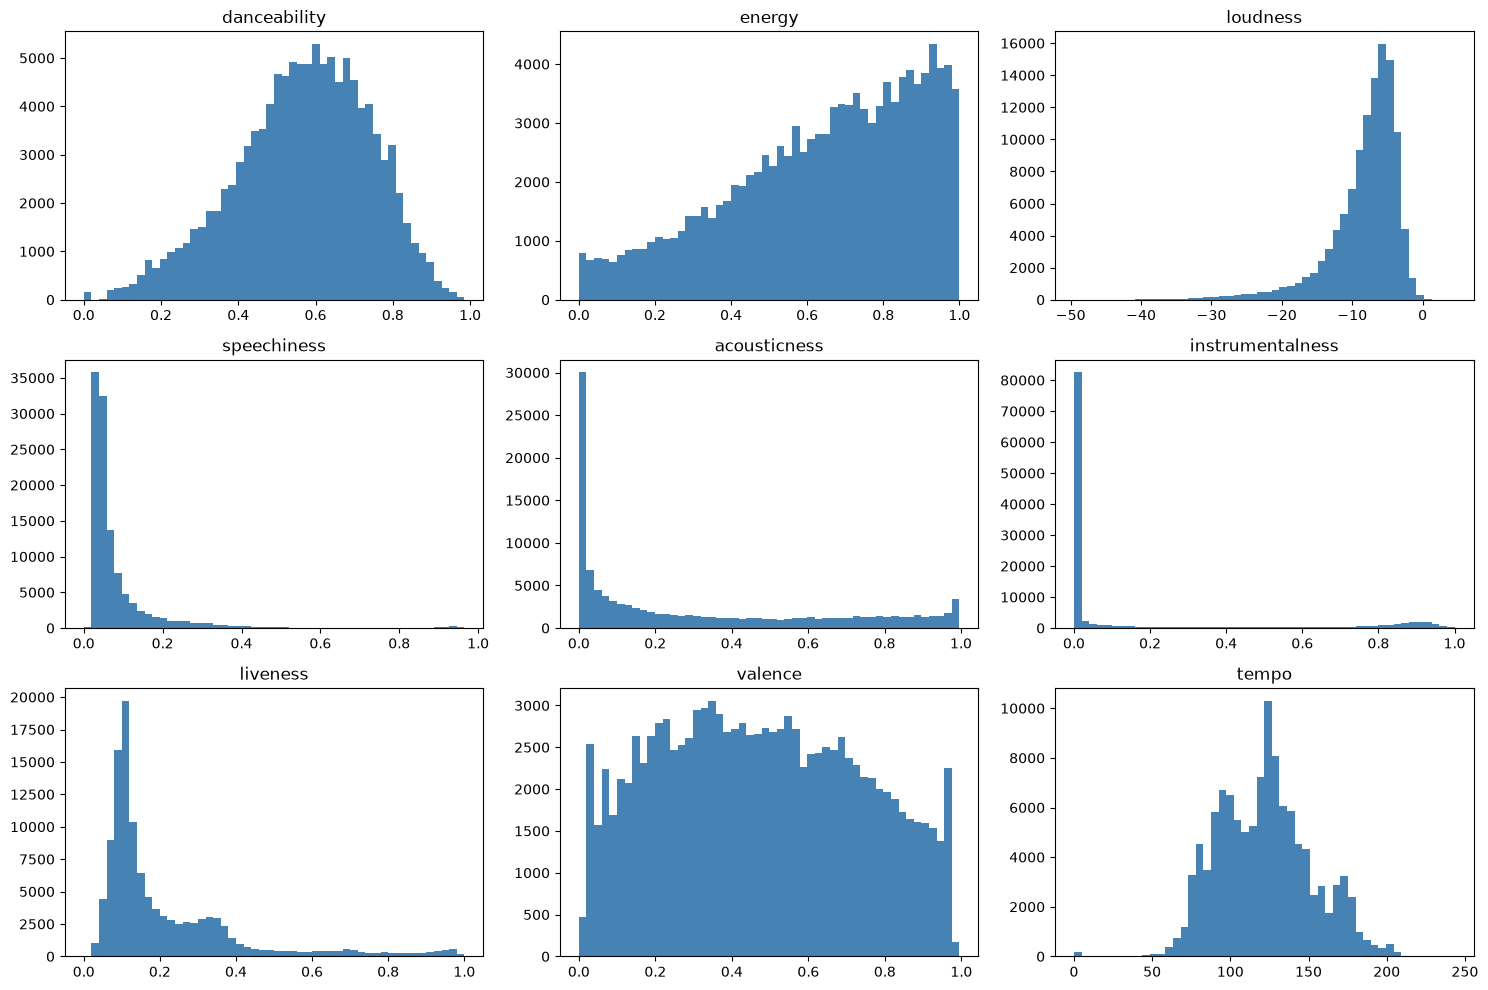

In [40]:
audio_features = ["danceability", "energy", "loudness", "speechiness",
                   "acousticness", "instrumentalness", "liveness", "valence", "tempo"]

fig, axes = plt.subplots(3, 3, figsize=(15, 10))
for ax, feat in zip(axes.flat, audio_features):
    ax.hist(tracks_df[feat].dropna(), bins=50, color="steelblue")
    ax.set_title(feat)
plt.tight_layout()
plt.savefig("outputs/figures/audio_feature_distributions.png", dpi=150)

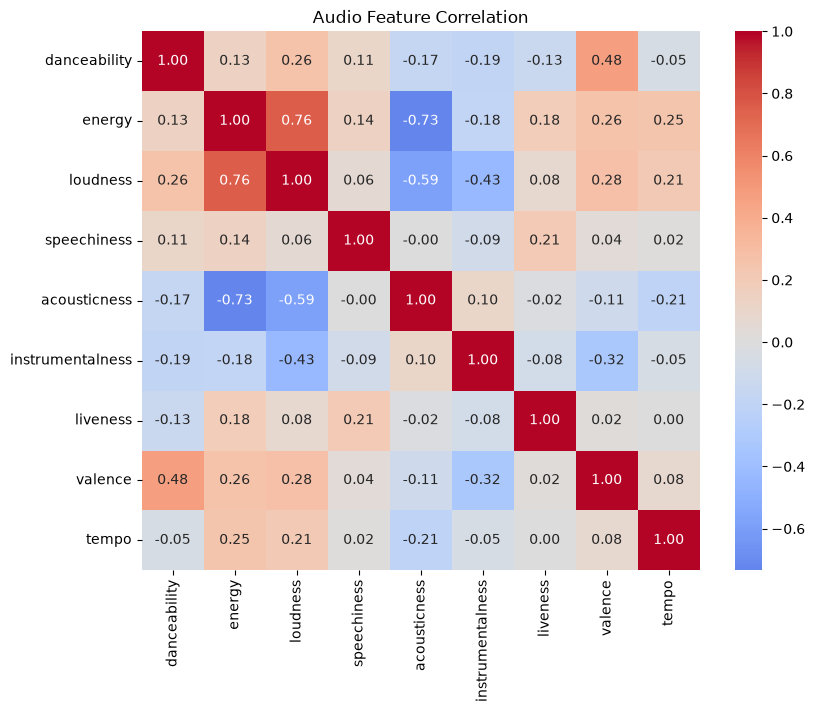

In [41]:
import seaborn as sns
plt.figure(figsize=(9, 7))
sns.heatmap(tracks_df[audio_features].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Audio Feature Correlation")
plt.savefig("outputs/figures/audio_feature_correlation.png", dpi=150)

In [42]:
lastfm_artists = set(interactions_sample["artist_name"].str.lower().str.strip())
spotify_artists = set(tracks_df["artists"].str.lower().str.strip())

overlap = lastfm_artists & spotify_artists
print(f"Last.fm artists in sample: {len(lastfm_artists):,}")
print(f"Spotify dataset artists:   {len(spotify_artists):,}")
print(f"Exact-match overlap:       {len(overlap):,} ({len(overlap)/len(lastfm_artists)*100:.1f}%)")

Last.fm artists in sample: 145,402
Spotify dataset artists:   31,429
Exact-match overlap:       6,381 (4.4%)


In [43]:
import re

def normalize_artist(name: str) -> str:
    name = name.lower().strip()
    name = re.sub(r"[^\w\s]", "", name)   # strip punctuation
    name = re.sub(r"\s+", " ", name)       # collapse whitespace
    return name

lastfm_norm = set(interactions_sample["artist_name"].dropna().apply(normalize_artist))

# Spotify 'artists' column often has multiple artists separated by ';' or ','
spotify_artists_split = tracks_df["artists"].dropna().str.split(r"[;,]").explode().str.strip()
spotify_norm = set(spotify_artists_split.apply(normalize_artist))

overlap_normalized = lastfm_norm & spotify_norm
print(f"Normalized Last.fm artists: {len(lastfm_norm):,}")
print(f"Normalized Spotify artists: {len(spotify_norm):,}")
print(f"Normalized overlap:         {len(overlap_normalized):,} ({len(overlap_normalized)/len(lastfm_norm)*100:.1f}%)")

Normalized Last.fm artists: 142,505
Normalized Spotify artists: 29,802
Normalized overlap:         9,256 (6.5%)


In [44]:
raw_preview1 = pd.read_csv(
    "../data/raw/lastfm/lastfm-dataset-360k/usersha1-artmbid-artname-plays.tsv",
    sep="\t", header=None
)

In [45]:
raw_preview

,0,1,2,3
0,00000c289a1829a808ac09c00daf10bc3c4e223b,3bd73256-3905-4f3a-97e2-8b341527f805,betty blowtorch,2137
1,00000c289a1829a808ac09c00daf10bc3c4e223b,f2fb0ff0-5679-42ec-a55c-15109ce6e320,die Ärzte,1099
2,00000c289a1829a808ac09c00daf10bc3c4e223b,b3ae82c2-e60b-4551-a76d-6620f1b456aa,melissa etheridge,897
3,00000c289a1829a808ac09c00daf10bc3c4e223b,3d6bbeb7-f90e-4d10-b440-e153c0d10b53,elvenking,717
4,00000c289a1829a808ac09c00daf10bc3c4e223b,bbd2ffd7-17f4-4506-8572-c1ea58c3f9a8,juliette & the licks,706
5,00000c289a1829a808ac09c00daf10bc3c4e223b,8bfac288-ccc5-448d-9573-c33ea2aa5c30,red hot chili peppers,691
6,00000c289a1829a808ac09c00daf10bc3c4e223b,6531c8b1-76ea-4141-b270-eb1ac5b41375,magica,545
7,00000c289a1829a808ac09c00daf10bc3c4e223b,21f3573f-10cf-44b3-aeaa-26cccd8448b5,the black dahlia murder,507
8,00000c289a1829a808ac09c00daf10bc3c4e223b,c5db90c4-580d-4f33-b364-fbaa5a3a58b5,the murmurs,424
9,00000c289a1829a808ac09c00daf10bc3c4e223b,0639533a-0402-40ba-b6e0-18b067198b73,lunachicks,403


In [46]:
import os
os.makedirs("../data/processed", exist_ok=True)

# Save the sampled, cleaned interactions
interactions_sample.to_parquet("../data/processed/interactions.parquet", index=False)

# Save tracks
tracks_df.to_parquet("../data/processed/tracks.parquet", index=False)

print(f"Saved interactions: {interactions_sample.shape}")
print(f"Saved tracks:       {tracks_df.shape}")

Saved interactions: (3664980, 3)
Saved tracks:       (114000, 21)
